# 07 · (선택) 동적계획법 — 해마다 비중을 다시 고르는 GBWM

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M8_%EC%8B%A4%EC%8A%B5_Colab/07_%EB%8F%99%EC%A0%81%EA%B3%84%ED%9A%8D%EB%B2%95_GBWM.ipynb)

강의본 51장 각주 "해마다 비중을 바꾸는 동적 문제는 동적계획법(자산 수준 × 시점 격자를 거꾸로 푼다)"의 실습입니다.
숫자의 출처는 보충교재 **13_GBWM_Series_DORS_zeroone**(Das · Ostrov · Radhakrishnan · Srivastav 연작 재계산) 17 · 18 · 20 · 23 · 39장입니다.

| 단계 | DORS 덱 | 이 노트북에서 |
|---|---|---|
| 손계산 — 2기간 · 5칸 · 포트폴리오 둘 | 17 · 18장 | 거꾸로 풀면 뒤처진 칸은 공격형, 앞선 칸은 보수형 → DP 0.647 vs 고정 A 0.149 · 고정 B 0.543 |
| 10년 두 배 | 20장 | 15개 포트폴리오 DP 66.6% vs 하나 고정 최고 49.8% (≥150은 77.7%) |
| TDF 비교 | 23장 | 50세 · 30년 · 납입/인출 — DP 58.6% vs TDF 25.6% |
| M8 세 목표 | 39장 | 6 · 9 · 14억을 95 · 70 · 30%로 — 필요 자본 약 6.2억(6.18억) |
| 전략 지도 | 20장 계열 | 자산이 적으면 공격형, 목표에 가까우면 보수형 |

**실행 시간** — 기본 모드 약 1분(M8 최소 자본 탐색이 가장 무겁다, 40초 안팎). `FAST = True`면 탐색을 건너뛰고 저장된 효용 가중치로 한 번만 풀어 10초 안팎.

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
`FAST = True`로 바꾸면 경로 수를 줄여 빨리 돌고, 이때 확인은 표시만 합니다.

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — True면 경로 · 표본 수를 줄여 빨리 끝난다(숫자가 강의와 소수 둘째 자리쯤 달라질 수 있어 확인은 표시만 한다)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 도구 — 효율선 · 격자 · 전이확률 · Bellman 역산
- **효율선**: 자산 셋(미국 채권 · 해외 주식 · 미국 주식)의 평균-분산 효율선 위에서 μ 등간격 15개 포트폴리오를 고른다. σ = √(aμ² + bμ + c).
- **격자**: ln W를 σ_min/ρ 간격으로 깔고(ρ = 3), W(0)이 격자점이 되게 민다.
- **전이확률**: 자산 Wi에서 포트폴리오 (μ, σ)를 1년 들면 Wj로 갈 확률 ∝ φ((ln(Wj/Wi) − (μ − σ²/2))/σ), j에 대해 합이 1이 되게 나눈다.
- **Bellman**: V(T) = 1{W ≥ G}, V(t, Wi) = max_μ Σj p(j | i, μ)·V(t+1, Wj) — t = T−1 … 0으로 거꾸로. 그다음 앞으로 확률을 전파.

In [2]:
MU3 = np.array([0.0493, 0.0770, 0.0886])                     # 2020 원문 표 1 — 미국 채권 · 해외 주식 · 미국 주식
SIG3 = np.array([[0.0017, -0.0017, -0.0021], [-0.0017, 0.0396, 0.0309], [-0.0021, 0.0309, 0.0392]])

def frontier(mu=MU3, S=SIG3):
    """σ = √(aμ² + bμ + c)의 a · b · c와 μ → 비중 함수"""
    Si = np.linalg.inv(S); o = np.ones(len(mu))
    k, l, m = mu @ Si @ o, mu @ Si @ mu, o @ Si @ o
    g = (l * Si @ o - k * Si @ mu) / (l * m - k * k); h = (m * Si @ mu - k * Si @ o) / (l * m - k * k)
    return h @ S @ h, 2 * g @ S @ h, g @ S @ g, (lambda x: g + h * x)

def snap(lo, hi, W0, step=None, n=None):
    """ln 등간격 격자를 만들고 W0가 격자점이 되도록 가장 적게 아래로 민다"""
    L0, L1, l0 = np.log(lo), np.log(hi), np.log(W0)
    if step is not None:
        lg = L0 + step * np.arange(int(np.ceil((L1 - L0) / step - 1e-12)) + 1)
    else:
        lg = np.linspace(L0, L1, n); step = lg[1] - lg[0]
    kk = int(np.ceil((l0 - L0) / step - 1e-12))
    return np.exp(lg - (L0 + kk * step - l0)), kk

def grid_2020(W0, T, mus, sigs, C=None, rho=3.0, wfloor=None):
    C = np.zeros(T + 1) if C is None else np.asarray(C, float)
    mn, mx, smin, smax = mus.min(), mus.max(), sigs.min(), sigs.max()
    dlo = lambda d: (mn - smax**2 / 2) * d - 3 * smax * np.sqrt(d)
    dhi = lambda d: (mx - smax**2 / 2) * d + 3 * smax * np.sqrt(d)
    lo = [W0 * np.exp(dlo(tau)) + sum(C[t] * np.exp(dlo(tau - t)) for t in range(1, tau + 1)) for tau in range(T + 1)]
    hi = [W0 * np.exp(dhi(tau)) + sum(C[t] * np.exp(dhi(tau - t)) for t in range(1, tau + 1)) for tau in range(T + 1)]
    Wlo, Whi = min(lo), max(hi)
    if Wlo <= 0 or wfloor is not None:
        Wlo = wfloor if wfloor is not None else 1.0
    return snap(Wlo, Whi, W0, step=smin / rho)

def grid_2022(W0, T, mus, sigs, imax, wb=1.0):
    mx, smin, smax = mus.max(), sigs.min(), sigs.max()
    d = lambda x: (mx - smin**2 / 2) * x + 3 * smax * np.sqrt(x)
    return snap(wb, max(W0 * np.exp(d(t)) for t in range(T + 1)), W0, n=imax)

def trans(X, W, mu, sg):
    """출발 금액 X(벡터)에서 격자 W로 가는 정규화 전이확률 행렬"""
    with np.errstate(divide="ignore", invalid="ignore"):
        z = (np.log(W)[None, :] - np.log(X)[:, None] - (mu - sg**2 / 2)) / sg
    e = -0.5 * z * z
    q = np.exp(e - e.max(1, keepdims=True))
    return q / q.sum(1, keepdims=True)

def solve(W, i0, T, mus, sigs, VT, cash=None):
    """Bellman 역산 + 앞으로 확률 전파. cash[t]는 해마다 미리 정한 납입(+) · 인출(−)"""
    n = len(W); cash = np.zeros(T + 1) if cash is None else np.asarray(cash, float)
    V = np.asarray(VT, float).copy(); L = np.zeros((T, n), int); Q = {}
    for t in range(T - 1, -1, -1):
        X = W + cash[t]; ok = X > 0
        Qt = [trans(np.where(ok, X, 1.0), W, m, s) for m, s in zip(mus, sigs)]
        EV = np.array([q @ V for q in Qt])
        L[t] = EV.argmax(0); V = np.where(ok, EV.max(0), 0.0); Q[t] = (Qt, ok)
        if t == 0: V0 = V[i0]
    Pt = np.zeros((T + 1, n)); Pt[0, i0] = 1.0
    for t in range(T):
        Qt, ok = Q[t]; nxt = np.zeros(n)
        for l in np.unique(L[t]):
            idx = np.where(ok & (L[t] == l) & (Pt[t] > 0))[0]
            if len(idx): nxt += Pt[t][idx] @ Qt[l][idx]
        Pt[t + 1] = nxt
    return dict(V0=V0, L=L, P=Pt)
print("도구 준비 완료")

도구 준비 완료


## 2. 손계산 — 2기간 · 5칸 · 포트폴리오 둘 (DORS 덱 17 · 18장)
자산 칸 W = 100 × e^(0.15k), k = −2 … 2 (74.1 · 86.1 · 100 · 116.2 · 135.0), 목표 110.
A = 보수형(μ 5.26%, σ 3.74%), B = 공격형(μ 8.86%, σ 19.54%). 5칸이라 끝에서 잘린 확률은 나눠 1로 맞춥니다.

In [3]:
Wh = 100 * np.exp(0.15 * np.arange(-2, 3)); Gh = 110
PH = [(0.0526, 0.0374), (0.0886, 0.1954)]
V2 = (Wh >= Gh).astype(float)
Qh = [trans(Wh, Wh, m, s) for m, s in PH]
print("자산 칸:", np.round(Wh, 1))
print(f"100에서 1년: A → 목표 칸(≥110) {Qh[0][2] @ V2:.1%} · B → {Qh[1][2] @ V2:.1%}")
E1 = np.array([q @ V2 for q in Qh]); V1 = E1.max(0); c1 = E1.argmax(0)
print("\n시점 1 — 칸마다 A · B의 기댓값과 선택")
for k in range(5):
    print(f"  W {Wh[k]:6.1f}: A {E1[0, k]:.3f} · B {E1[1, k]:.3f} → {'AB'[c1[k]]}")
E0 = np.array([q[2] @ V1 for q in Qh])
fixedA = Qh[0][2] @ (Qh[0] @ V2); fixedB = Qh[1][2] @ (Qh[1] @ V2)
print(f"\n시점 0 (자산 100): A로 시작 {E0[0]:.3f} · B로 시작 {E0[1]:.3f} → DP = {E0.max():.3f}")
print(f"비교: 두 해 모두 A 고정 {fixedA:.3f} · 모두 B 고정 {fixedB:.3f}")
check("A의 목표 칸 확률 (%)", 100 * (Qh[0][2] @ V2), 7.7, 0.05, ".1f"); check("B의 목표 칸 확률 (%)", 100 * (Qh[1][2] @ V2), 46.4, 0.05, ".1f")
check("손계산 DP", E0.max(), 0.647, 0.0005, ".3f"); check("고정 A", fixedA, 0.149, 0.0005, ".3f"); check("고정 B", fixedB, 0.543, 0.0005, ".3f")
assert list(c1) == [1, 1, 1, 0, 0], "목표 아래 칸은 B, 위 칸은 A"

자산 칸: [ 74.1  86.1 100.  116.2 135. ]
100에서 1년: A → 목표 칸(≥110) 7.7% · B → 46.4%

시점 1 — 칸마다 A · B의 기댓값과 선택
  W   74.1: A 0.000 · B 0.069 → B
  W   86.1: A 0.000 · B 0.214 → B
  W  100.0: A 0.077 · B 0.464 → B
  W  116.2: A 1.000 · B 0.718 → A
  W  135.0: A 1.000 · B 0.881 → A

시점 0 (자산 100): A로 시작 0.505 · B로 시작 0.647 → DP = 0.647
비교: 두 해 모두 A 고정 0.149 · 모두 B 고정 0.543
✓ A의 목표 칸 확률 (%): 계산 7.7 · 강의 7.7 (허용 ±0.05)
✓ B의 목표 칸 확률 (%): 계산 46.4 · 강의 46.4 (허용 ±0.05)
✓ 손계산 DP: 계산 0.647 · 강의 0.647 (허용 ±0.0005)
✓ 고정 A: 계산 0.149 · 강의 0.149 (허용 ±0.0005)
✓ 고정 B: 계산 0.543 · 강의 0.543 (허용 ±0.0005)


## 3. 10년 두 배 — 15개 포트폴리오 DP (DORS 덱 20장)
W(0) = 100, 목표 G = 200, T = 10년, 연 재조정. 15개 포트폴리오는 효율선 위 μ 5.26% ~ 8.86% 등간격.

In [4]:
a_, b_, c_, wf = frontier()
mus = np.linspace(0.0526, 0.0886, 15); sigs = np.sqrt(a_ * mus**2 + b_ * mus + c_)
T = 10
t0 = time.time()
W, i0 = grid_2020(100, T, mus, sigs)
res = solve(W, i0, T, mus, sigs, (W >= 200).astype(float))
P200, P150 = res["V0"], res["P"][-1][W >= 150].sum()
l0 = res["L"][0][i0]
print(f"효율선 a {a_:.4f} · b {b_:.4f} · c {c_:.5f} · σ {sigs[0]:.4f} ~ {sigs[-1]:.4f} · 격자 {len(W)}칸 · {time.time() - t0:.2f}초")
print(f"DP: P[W(10) ≥ 200] = {P200:.1%} · P[W(10) ≥ 150] = {P150:.1%} · 시작 포트폴리오 {l0}번 (μ {mus[l0]:.2%}, σ {sigs[l0]:.2%})")

def fixed_prob(l):
    Pv = np.zeros(len(W)); Pv[i0] = 1.0; q = trans(W, W, mus[l], sigs[l])
    for _ in range(T): Pv = Pv @ q
    return Pv[W >= 200].sum()
fx = np.array([fixed_prob(l) for l in range(15)])
print(f"하나를 10년 고정했을 때 최고 = {fx.max():.1%} ({fx.argmax()}번) → DP가 {100 * (P200 - fx.max()):.1f}%p 높다")
check("DP 10년 두 배 (%)", 100 * P200, 66.6, 0.05, ".1f"); check("DP ≥150 (%)", 100 * P150, 77.7, 0.05, ".1f")
check("고정 최고 (%)", 100 * fx.max(), 49.8, 0.05, ".1f"); check("시작 포트폴리오 번호", l0, 12, 0, ".0f")

효율선 a 28.3286 · b -2.9759 · c 0.07952 · σ 0.0371 ~ 0.1956 · 격자 331칸 · 0.08초
DP: P[W(10) ≥ 200] = 66.6% · P[W(10) ≥ 150] = 77.7% · 시작 포트폴리오 12번 (μ 8.35%, σ 16.88%)
하나를 10년 고정했을 때 최고 = 49.8% (14번) → DP가 16.8%p 높다
✓ DP 10년 두 배 (%): 계산 66.6 · 강의 66.6 (허용 ±0.05)
✓ DP ≥150 (%): 계산 77.7 · 강의 77.7 (허용 ±0.05)
✓ 고정 최고 (%): 계산 49.8 · 강의 49.8 (허용 ±0.05)
✓ 시작 포트폴리오 번호: 계산 12 · 강의 12 (허용 ±0)


**그래프 — 전략 지도 히트맵.** 시점(가로) × 자산(세로, 로그)마다 DP가 고른 포트폴리오 번호(0 = 가장 보수적, 14 = 가장 공격적).
자산이 목표에서 멀면 공격형, 목표에 가까워지거나 넘으면 보수형으로 — 시점이 다가올수록 경계가 목표 200 쪽으로 올라갑니다.
(목표를 이미 넘은 칸은 어느 포트폴리오든 확률이 거의 1이라 번호가 섞여 보입니다.)

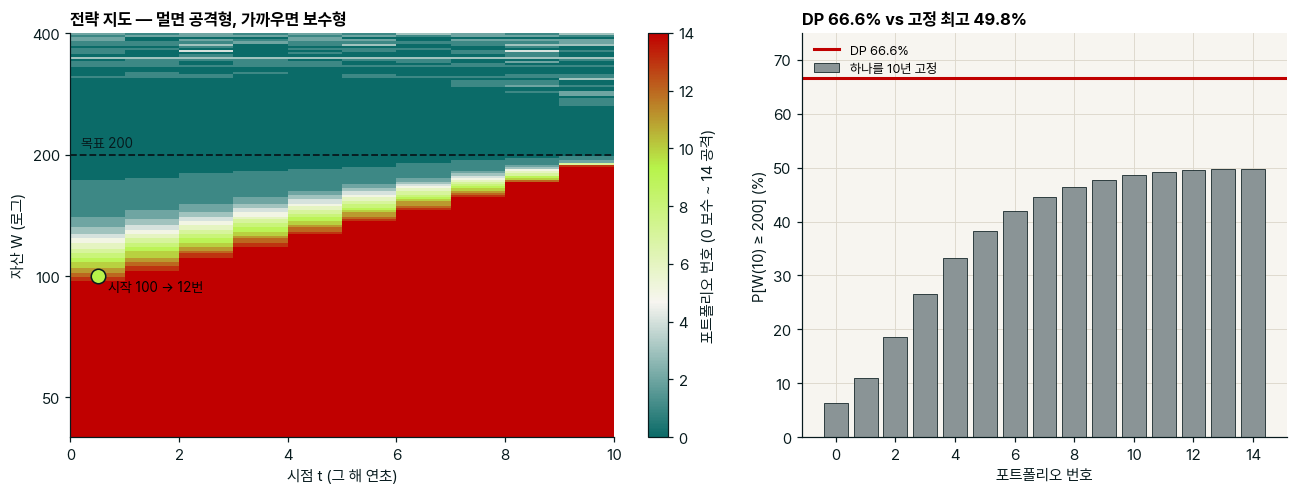

In [5]:
from matplotlib.colors import LinearSegmentedColormap
cm = LinearSegmentedColormap.from_list("risk", [TEAL, IVORY, LIME, RED])
sel = (W >= 40) & (W <= 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.4, 1]})
im = ax1.pcolormesh(np.arange(T) + 0.5, W[sel], res["L"][:, sel].T, cmap=cm, shading="nearest", vmin=0, vmax=14)
ax1.set_yscale("log"); ax1.axhline(200, color=INK, ls="--", lw=1.2); ax1.text(0.2, 210, "목표 200", fontsize=9, color=INK)
ax1.scatter(0.5, 100, s=90, color=LIME, edgecolor=INK, zorder=5); ax1.text(0.7, 92, f"시작 100 → {l0}번", fontsize=9)
cb = fig.colorbar(im, ax=ax1); cb.set_label("포트폴리오 번호 (0 보수 ~ 14 공격)")
ax1.set_yticks([50, 100, 200, 400], ["50", "100", "200", "400"]); ax1.minorticks_off()
ax1.set_xlabel("시점 t (그 해 연초)"); ax1.set_ylabel("자산 W (로그)")
ax1.set_title("전략 지도 — 멀면 공격형, 가까우면 보수형", fontsize=11)
ax2.bar(np.arange(15), fx * 100, color=GRAY, edgecolor=INK, lw=0.5, label="하나를 10년 고정")
ax2.axhline(P200 * 100, color=RED, lw=2, label=f"DP {P200:.1%}")
ax2.set_xlabel("포트폴리오 번호"); ax2.set_ylabel("P[W(10) ≥ 200] (%)"); ax2.set_ylim(0, 75)
ax2.set_title(f"DP {P200:.1%} vs 고정 최고 {fx.max():.1%}", fontsize=11); ax2.legend(loc="upper left", fontsize=8.5)
fig.tight_layout(); plt.show()

## 4. TDF 비교 — 50세 · 30년 · 납입과 인출 (DORS 덱 23장)
50세에 10만, 65세까지 연 c = 15 납입(연 3% 증가), 66~80세 연 5만(실질, 연 3% 증가) 인출, 목표 = 80세에 50 × 1.03³⁰ 이상(지급 능력).
DP는 같은 15개 포트폴리오에서 해마다 고르고, TDF는 나이로만 정한 세 펀드 비중(원문 표 8)을 20만 경로로 모의합니다.

In [6]:
T30, G30 = 30, 50 * 1.03**30
Cf = np.zeros(T30 + 1)
for t in range(1, 16): Cf[t] = 15 * 1.03**t
for t in range(16, 30): Cf[t] = -50 * 1.03**t
t0 = time.time()
Wr, ir = grid_2020(100, T30, mus, sigs, C=Cf, wfloor=1.0)
rr = solve(Wr, ir, T30, mus, sigs, (Wr >= G30).astype(float), cash=Cf)
glide = [(50, 54, [.27, .29, .44]), (55, 59, [.34, .26, .40]), (60, 64, [.42, .23, .35]),
         (65, 69, [.53, .19, .28]), (70, 74, [.67, .13, .20]), (75, 80, [.70, .12, .18])]
gw = lambda age: next(np.array(w) for lo, hi, w in glide if lo <= age <= hi)
NT = 40_000 if FAST else 200_000
Z = np.random.default_rng(2026).standard_normal((NT, T30))
X = np.full(NT, 100.0); alive = np.ones(NT, bool)
for t in range(T30):
    X = X + Cf[t]; alive &= X > 0; X = np.where(alive, X, 0)
    w = gw(50 + t); m = w @ MU3; s = np.sqrt(w @ SIG3 @ w)
    X = X * np.exp(m - s * s / 2 + s * Z[:, t])
p_tdf = np.mean(alive & (X >= G30))
print(f"격자 {len(Wr)}칸 · {time.time() - t0:.1f}초 · DP {rr['V0']:.1%} vs TDF {p_tdf:.1%} (모의 {NT:,})")
check("TDF 비교 DP (%)", 100 * rr["V0"], 58.6, 0.05, ".1f"); check("TDF (%)", 100 * p_tdf, 25.6, 0.05, ".1f")

격자 835칸 · 2.1초 · DP 58.6% vs TDF 25.6% (모의 200,000)
✓ TDF 비교 DP (%): 계산 58.6 · 강의 58.6 (허용 ±0.05)
✓ TDF (%): 계산 25.6 · 강의 25.6 (허용 ±0.05)


## 5. M8 세 목표를 DP로 — 필요 자본 약 6.2억 (DORS 덱 39장)
강의본의 55세 · 10년 · 세 기준선 6 · 9 · 14억을 95 · 70 · 30%로. 포트폴리오는 GHP와 주식을 0~100%(5%p) 섞은 21개
(μ = 2% + 6%·w, σ = 20%·w). 해마다 비중을 다시 고르고, 시점 10의 가치는 **효용 가중합** U₁·1{W ≥ 6} + U₂·1{W ≥ 9} + U₃·1{W ≥ 14}.
① 효용 가중치 U를 바꿔 가며 세 확률이 목표(95 · 70 · 30%)에 가장 가까운 점을 찾고(근접점) ② 그 거리가 0이 되는 가장 작은 초기 자금을 할선법으로 찾습니다.
비교: 방법 1 계좌 분리 9.13억 · 방법 3 한 계좌 고정 비중 7.1억(48장) · DP 6.18억.

In [7]:
wq = np.linspace(0, 1, 21); mu8 = 0.02 + 0.06 * wq; sg8 = np.maximum(0.2 * wq, 0.004)
TGT = np.array([0.95, 0.70, 0.30])

def p8(W0, U):
    Wg, ig = grid_2022(W0, 10, mu8, sg8, 400, wb=0.5)
    VT = U[0] * (Wg >= 6) + U[1] * (Wg >= 9) + U[2] * (Wg >= 14)
    rg = solve(Wg, ig, 10, mu8, sg8, VT)
    PT = rg["P"][-1]
    return np.array([PT[Wg >= L - 1e-9].sum() for L in (6, 9, 14)]), rg, Wg, ig

def proximity(pfun, d, U0=None, it=80, tol=2e-3):
    """근접점 — U ← U + ΔU (d − p), 거리가 늘면 ΔU를 70%로 줄인다. 반환 (p, U, 부호 거리)"""
    U = np.full(len(d), 100.0) if U0 is None else np.asarray(U0, float)
    p = pfun(U); dU = 0.99 * U.mean()
    for _ in range(it):
        while True:
            Un = np.maximum(U + dU * (d - p), 1e-3 * U.mean()); pn = pfun(Un)
            if np.linalg.norm(d - pn) <= np.linalg.norm(d - p) + 1e-12 or dU < 1e-3: break
            dU *= 0.7
        U, p = Un, pn; e = d - p
        if np.linalg.norm(e) < 1e-4: break
        sgn = 1.0 if e.sum() >= 0 else -1.0
        if np.linalg.norm(U / np.linalg.norm(U) - sgn * e / np.linalg.norm(e)) < tol: break
    e = d - p; dist = np.linalg.norm(e)
    return p, U, (dist if np.all(e >= -1e-9) or e.sum() > 0 else -dist)

def min_wealth(d, w_lo, w_hi, tol=2e-3, it=10):
    """초기 자금 → 근접점의 부호 거리, 0이 되는 자금을 할선법으로"""
    pts = []; U = None
    for x in (w_lo, w_hi):
        p, U, s = proximity(lambda u: p8(x, u)[0], d, U0=U); pts.append((x, s, p, U))
        print(f"  자금 {x:.3f}억 → 확률 {np.round(p, 3)} · 부호 거리 {s:+.4f}")
    for _ in range(it):
        (x0, f0, *_), (x1, f1, *_) = pts[-2], pts[-1]
        if f1 == f0: break
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        p, U, s = proximity(lambda u: p8(x2, u)[0], d, U0=pts[-1][3]); pts.append((x2, s, p, U))
        print(f"  자금 {x2:.3f}억 → 확률 {np.round(p, 3)} · 부호 거리 {s:+.4f}")
        if abs(s) < tol: break
    return pts[-1]

t0 = time.time()
if FAST:
    W_min, U8 = 6.18161362974777, np.array([1.0, 0.3660153065586931, 0.2680052290205285])   # 기본 모드 탐색 결과(DORS 덱 계산값)
    print("빠른 모드 — 탐색을 건너뛰고 저장된 자금 · 효용 가중치로 한 번만 푼다")
else:
    print("최소 자금 탐색(할선법 × 근접점) — 40초 안팎")
    W_min, _, _, U8 = min_wealth(TGT, 6.0, 8.0)
p_min, r8, W8, i8 = p8(W_min, U8)
U8 = U8 / U8[0]
print(f"\n필요 자본 {W_min:.2f}억 · 확률 {p_min[0]:.1%} · {p_min[1]:.1%} · {p_min[2]:.1%} · 효용 1 : {U8[1]:.2f} : {U8[2]:.2f} · "
      f"시작 주식 {wq[r8['L'][0][i8]]:.0%} · {time.time() - t0:.1f}초")
check("M8 DP 필요 자본 (억)", W_min, 6.18, 0.005, ".2f")
for nm, v, l in zip(["Safety ≥6억", "Market ≥9억", "Aspirational ≥14억"], p_min, (94.9, 70.0, 30.0)):
    check(f"DP 확률 {nm} (%)", 100 * v, l, 0.05, ".1f")
check("효용 U₂", U8[1], 0.37, 0.005, ".2f"); check("효용 U₃", U8[2], 0.27, 0.005, ".2f")
check("시작 주식 비중 (%)", 100 * wq[r8["L"][0][i8]], 80, 0, ".0f")

최소 자금 탐색(할선법 × 근접점) — 40초 안팎


  자금 6.000억 → 확률 [0.928 0.69  0.292] · 부호 거리 +0.0254


  자금 8.000억 → 확률 [1.    0.876 0.477] · 부호 거리 -0.2544


  자금 6.182억 → 확률 [0.949 0.7   0.3  ] · 부호 거리 +0.0008

필요 자본 6.18억 · 확률 94.9% · 70.0% · 30.0% · 효용 1 : 0.37 : 0.27 · 시작 주식 80% · 44.0초
✓ M8 DP 필요 자본 (억): 계산 6.18 · 강의 6.18 (허용 ±0.005)
✓ DP 확률 Safety ≥6억 (%): 계산 94.9 · 강의 94.9 (허용 ±0.05)
✓ DP 확률 Market ≥9억 (%): 계산 70.0 · 강의 70.0 (허용 ±0.05)
✓ DP 확률 Aspirational ≥14억 (%): 계산 30.0 · 강의 30.0 (허용 ±0.05)
✓ 효용 U₂: 계산 0.37 · 강의 0.37 (허용 ±0.005)
✓ 효용 U₃: 계산 0.27 · 강의 0.27 (허용 ±0.005)
✓ 시작 주식 비중 (%): 계산 80 · 강의 80 (허용 ±0)


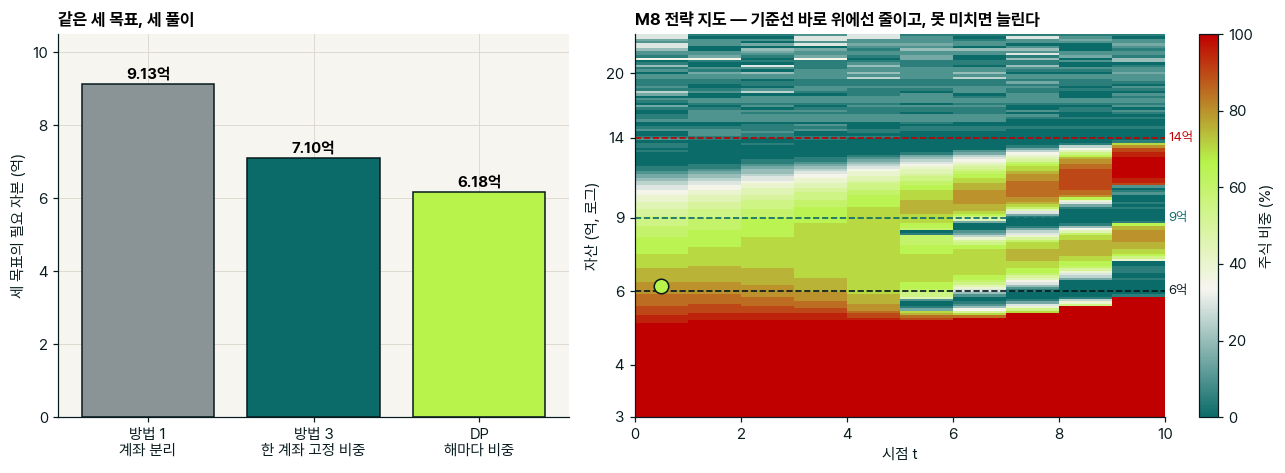

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1, 1.3]})
labs = ["방법 1\n계좌 분리", "방법 3\n한 계좌 고정 비중", "DP\n해마다 비중"]
vals = [9.13, 7.1, W_min]
bars = ax1.bar(labs, vals, color=[GRAY, TEAL, LIME], edgecolor=INK)
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width() / 2, v + 0.15, f"{v:.2f}억", ha="center", fontsize=10, fontweight="bold")
ax1.set_ylim(0, 10.5); ax1.set_ylabel("세 목표의 필요 자본 (억)")
ax1.set_title("같은 세 목표, 세 풀이", fontsize=11)
sel = (W8 >= 3) & (W8 <= 25)
L8 = r8["L"][:, sel].T
im = ax2.pcolormesh(np.arange(10) + 0.5, W8[sel], wq[L8] * 100, cmap=LinearSegmentedColormap.from_list("w", [TEAL, IVORY, LIME, RED]),
                    shading="nearest", vmin=0, vmax=100)
for L, c in zip((6, 9, 14), (INK, TEAL, RED)):
    ax2.axhline(L, color=c, ls="--", lw=1.1); ax2.text(10.05, L, f"{L}억", va="center", fontsize=8.5, color=c)
ax2.scatter(0.5, W_min, s=90, color=LIME, edgecolor=INK, zorder=5)
ax2.set_yscale("log"); ax2.set_yticks([3, 4, 6, 9, 14, 20], ["3", "4", "6", "9", "14", "20"]); ax2.minorticks_off()
ax2.set_xlabel("시점 t"); ax2.set_ylabel("자산 (억, 로그)")
cb = fig.colorbar(im, ax=ax2); cb.set_label("주식 비중 (%)")
ax2.set_title("M8 전략 지도 — 기준선 바로 위에선 줄이고, 못 미치면 늘린다", fontsize=11)
fig.tight_layout(); plt.show()

**읽는 법** — DP는 자산이 기준선(6 · 9 · 14억) 바로 위면 주식을 줄여 지키고, 기준선에 못 미치면 주식을 늘려 노립니다. 다만 Safety가 GHP 확정이 아니라 **확률 95%** 로 바뀝니다.
Safety를 확정으로 둘지(방법 1) 확률로 둘지(DP)가 약 3억 차이의 대가 — IC가 정할 정책입니다.

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [9]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 18 / 18 통과


---
## 바꿔 보기 (연습 문제)

1. 10년 두 배 예에서 목표를 200 → 150으로 낮추면(`(W >= 150)`으로 다시 풀기) DP와 고정 최고의 차이는 줄어드는가?
2. TDF 비교에서 연 납입 c를 15 → 24로 올리면 TDF 확률이 DP의 58.6%에 닿는가? (DORS 덱 23장: '약 24')
3. M8 DP에서 주식 비중 상한을 70%로 두면(`wq <= 0.7`인 포트폴리오만) 같은 자금 6.18억에서 세 확률은? (덱: 93.9 · 69.0 · 28.9%)

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [10]:
# 여기에 직접 해 보기

In [11]:
# 여기에 직접 해 보기

In [12]:
# 여기에 직접 해 보기